# Analyze Overlap Between Hospital A and B

This notebook measures the overlap of clinical resources (Conditions, Medications, Procedures) between hospital_A and hospital_B bundles for different split strategies.

Analysis includes:
- **Temporal Split**: Split patients based on encounter dates
- **Location Split**: Split patients based on encounter locations

For each strategy, we calculate overlap metrics such as Jaccard index, intersection count, and overlap percentages.

## Load Graphs and Resources

Load FHIR graphs and resources using build_fhir_graphs(). Patient bundles are loaded from both hospital_A and hospital_B directories for each strategy.

In [27]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [39]:
import json
from pathlib import Path
from collections import defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [29]:
def load_bundles_from_disk(strategy_name, hospital):
    """Load patient bundles from disk for a given strategy and hospital."""
    bundle_dir = Path(f"input/{strategy_name}/{hospital}")
    bundles = {}
    
    if not bundle_dir.exists():
        print(f"Warning: Directory {bundle_dir} does not exist")
        return bundles
    
    for bundle_file in bundle_dir.glob("*.json"):
        with open(bundle_file, 'r', encoding='utf-8') as f:
            bundle = json.load(f)
            patient_uuid = bundle_file.stem
            bundles[patient_uuid] = bundle
    
    return bundles

# Load bundles for all strategies and hospitals
strategies = ["temporal", "location"]
loaded_bundles = {}

for strategy in strategies:
    loaded_bundles[strategy] = {
        "hospital_A": load_bundles_from_disk(strategy, "hospital_A"),
        "hospital_B": load_bundles_from_disk(strategy, "hospital_B")
    }
    print(f"{strategy.capitalize()} strategy:")
    print(f"  Hospital A: {len(loaded_bundles[strategy]['hospital_A'])} bundles")
    print(f"  Hospital B: {len(loaded_bundles[strategy]['hospital_B'])} bundles")

Temporal strategy:
  Hospital A: 100 bundles
  Hospital B: 100 bundles
Location strategy:
  Hospital A: 100 bundles
  Hospital B: 100 bundles


## Define Overlap Analysis Functions

Helper functions to extract clinical resources and calculate overlap metrics between hospital_A and hospital_B bundles.

In [30]:
def extract_clinical_codes(bundle, resource_type):
    """Extract clinical codes from a specific resource type in a FHIR bundle."""
    codes = set()
    
    if "entry" not in bundle:
        return codes
    
    for entry in bundle.get("entry", []):
        resource = entry.get("resource", {})
        if resource.get("resourceType") == resource_type:
            # Extract code(s) from the resource based on type
            if resource_type == "Condition":
                coding = resource.get("code", {}).get("coding", [])
            elif resource_type == "Medication":
                coding = resource.get("code", {}).get("coding", [])
            elif resource_type == "Procedure":
                coding = resource.get("code", {}).get("coding", [])
            else:
                coding = []
            
            # Extract system + code as a unique identifier
            for c in coding:
                system = c.get("system", "")
                code = c.get("code", "")
                if system and code:
                    codes.add(f"{system}#{code}")
    
    return codes

def extract_resource_ids(bundle, resource_types):
    """Extract resource IDs of specified types from a FHIR bundle."""
    resource_ids = set()
    
    if "entry" not in bundle:
        return resource_ids
    
    for entry in bundle.get("entry", []):
        resource = entry.get("resource", {})
        if resource.get("resourceType") in resource_types:
            resource_id = resource.get("id")
            if resource_id:
                resource_ids.add(resource_id)
    
    return resource_ids

def calculate_overlap_metrics(set_a, set_b):
    """Calculate overlap metrics between two sets."""
    intersection = set_a & set_b
    union = set_a | set_b
    
    # Avoid division by zero
    if len(union) == 0:
        jaccard_index = 1.0 if len(set_a) == 0 and len(set_b) == 0 else 0.0
    else:
        jaccard_index = len(intersection) / len(union)
    
    # Overlap percentage relative to each set
    overlap_pct_a = (len(intersection) / len(set_a) * 100) if len(set_a) > 0 else 0.0
    overlap_pct_b = (len(intersection) / len(set_b) * 100) if len(set_b) > 0 else 0.0
    
    return {
        "intersection_count": len(intersection),
        "union_count": len(union),
        "jaccard_index": jaccard_index,
        "overlap_pct_a": overlap_pct_a,
        "overlap_pct_b": overlap_pct_b,
        "avg_overlap_pct": (overlap_pct_a + overlap_pct_b) / 2
    }

def analyze_overlap_for_strategy(strategy_name, bundles, resource_types):
    """Analyze overlap for a specific strategy and resource types (based on clinical codes)."""
    hospital_a_bundles = bundles[strategy_name]["hospital_A"]
    hospital_b_bundles = bundles[strategy_name]["hospital_B"]
    
    # Get common patients (those with bundles in both hospitals)
    common_patients = set(hospital_a_bundles.keys()) & set(hospital_b_bundles.keys())
    
    results = {
        "strategy": strategy_name,
        "patients_total": len(set(hospital_a_bundles.keys()) | set(hospital_b_bundles.keys())),
        "patients_split": len(common_patients),
        "resource_types": {}
    }
    
    for resource_type in resource_types:
        overlap_data = []
        
        for patient_uuid in common_patients:
            bundle_a = hospital_a_bundles[patient_uuid]
            bundle_b = hospital_b_bundles[patient_uuid]
            
            # Extract clinical codes instead of resource IDs
            codes_a = extract_clinical_codes(bundle_a, resource_type)
            codes_b = extract_clinical_codes(bundle_b, resource_type)
            
            # Only consider patients with resources in at least one bundle
            if len(codes_a) > 0 or len(codes_b) > 0:
                metrics = calculate_overlap_metrics(codes_a, codes_b)
                metrics["patient_uuid"] = patient_uuid
                metrics["count_a"] = len(codes_a)
                metrics["count_b"] = len(codes_b)
                overlap_data.append(metrics)
        
        # Aggregate statistics
        if overlap_data:
            jaccard_indices = [d["jaccard_index"] for d in overlap_data]
            overlap_a_pcts = [d["overlap_pct_a"] for d in overlap_data]
            overlap_b_pcts = [d["overlap_pct_b"] for d in overlap_data]
            
            results["resource_types"][resource_type] = {
                "patients_with_resource": len(overlap_data),
                "jaccard_mean": np.mean(jaccard_indices),
                "jaccard_median": np.median(jaccard_indices),
                "jaccard_std": np.std(jaccard_indices),
                "overlap_pct_a_mean": np.mean(overlap_a_pcts),
                "overlap_pct_b_mean": np.mean(overlap_b_pcts),
                "overlap_pct_mean": (np.mean(overlap_a_pcts) + np.mean(overlap_b_pcts)) / 2,
                "intersection_total": sum(d["intersection_count"] for d in overlap_data),
                "overlap_data": overlap_data
            }
        else:
            results["resource_types"][resource_type] = {
                "patients_with_resource": 0,
                "note": "No resources found"
            }
    
    return results

print("Overlap analysis functions defined successfully!")

Overlap analysis functions defined successfully!


## Analyze Temporal Split Strategy

Load temporal split bundles and analyze conditions, medications, and procedures overlap between hospital_A and hospital_B.

In [31]:
resource_types = ["Condition", "Medication", "Procedure"]

print("=" * 80)
print("TEMPORAL SPLIT STRATEGY - OVERLAP ANALYSIS")
print("=" * 80)

temporal_results = analyze_overlap_for_strategy("temporal", loaded_bundles, resource_types)

print(f"\nTotal patients: {temporal_results['patients_total']}")
print(f"Patients with split encounters: {temporal_results['patients_split']}\n")

temporal_summary = {}
for resource_type in resource_types:
    data = temporal_results["resource_types"][resource_type]
    temporal_summary[resource_type] = data
    
    print(f"{resource_type}s:")
    print(f"  Patients with resources: {data.get('patients_with_resource', 0)}")
    
    if data.get('patients_with_resource', 0) > 0:
        print(f"  Jaccard Index - Mean: {data['jaccard_mean']:.4f}, Median: {data['jaccard_median']:.4f}, Std: {data['jaccard_std']:.4f}")
        print(f"  Overlap % (A): {data['overlap_pct_a_mean']:.2f}%")
        print(f"  Overlap % (B): {data['overlap_pct_b_mean']:.2f}%")
        print(f"  Average Overlap %: {data['overlap_pct_mean']:.2f}%")
        print(f"  Total Overlapping Resources: {data['intersection_total']}")
    else:
        print(f"  {data.get('note', 'No data')}")
    print()

TEMPORAL SPLIT STRATEGY - OVERLAP ANALYSIS

Total patients: 100
Patients with split encounters: 100

Conditions:
  Patients with resources: 100
  Jaccard Index - Mean: 0.0651, Median: 0.0000, Std: 0.1013
  Overlap % (A): 11.63%
  Overlap % (B): 11.29%
  Average Overlap %: 11.46%
  Total Overlapping Resources: 282

Medications:
  Patients with resources: 100
  Jaccard Index - Mean: 0.0040, Median: 0.0000, Std: 0.0085
  Overlap % (A): 1.06%
  Overlap % (B): 0.70%
  Average Overlap %: 0.88%
  Total Overlapping Resources: 32

Procedures:
  Patients with resources: 100
  Jaccard Index - Mean: 0.0420, Median: 0.0000, Std: 0.0920
  Overlap % (A): 8.37%
  Overlap % (B): 8.66%
  Average Overlap %: 8.51%
  Total Overlapping Resources: 77



## Analyze Location Split Strategy

Load location split bundles and perform the same overlap analysis. Compare results with temporal split metrics.

In [32]:
print("=" * 80)
print("LOCATION SPLIT STRATEGY - OVERLAP ANALYSIS")
print("=" * 80)

location_results = analyze_overlap_for_strategy("location", loaded_bundles, resource_types)

print(f"\nTotal patients: {location_results['patients_total']}")
print(f"Patients with split encounters: {location_results['patients_split']}\n")

location_summary = {}
for resource_type in resource_types:
    data = location_results["resource_types"][resource_type]
    location_summary[resource_type] = data
    
    print(f"{resource_type}s:")
    print(f"  Patients with resources: {data.get('patients_with_resource', 0)}")
    
    if data.get('patients_with_resource', 0) > 0:
        print(f"  Jaccard Index - Mean: {data['jaccard_mean']:.4f}, Median: {data['jaccard_median']:.4f}, Std: {data['jaccard_std']:.4f}")
        print(f"  Overlap % (A): {data['overlap_pct_a_mean']:.2f}%")
        print(f"  Overlap % (B): {data['overlap_pct_b_mean']:.2f}%")
        print(f"  Average Overlap %: {data['overlap_pct_mean']:.2f}%")
        print(f"  Total Overlapping Resources: {data['intersection_total']}")
    else:
        print(f"  {data.get('note', 'No data')}")
    print()

LOCATION SPLIT STRATEGY - OVERLAP ANALYSIS

Total patients: 100
Patients with split encounters: 100

Conditions:
  Patients with resources: 100
  Jaccard Index - Mean: 0.0639, Median: 0.0000, Std: 0.1035
  Overlap % (A): 12.35%
  Overlap % (B): 11.11%
  Average Overlap %: 11.73%
  Total Overlapping Resources: 344

Medications:
  Patients with resources: 100
  Jaccard Index - Mean: 0.0037, Median: 0.0000, Std: 0.0099
  Overlap % (A): 1.13%
  Overlap % (B): 0.62%
  Average Overlap %: 0.87%
  Total Overlapping Resources: 32

Procedures:
  Patients with resources: 100
  Jaccard Index - Mean: 0.0224, Median: 0.0000, Std: 0.0543
  Overlap % (A): 6.20%
  Overlap % (B): 3.43%
  Average Overlap %: 4.82%
  Total Overlapping Resources: 54



## Additional Statistics: Encounter Overlap, Diagnosis Categories, and Location Diversity

Calculate encounter overlap, diagnosis category overlap, and location diversity retention to assess how well strategies differentiate between hospitals.


In [33]:
def extract_encounters(bundle):
    """Extract encounter IDs from a FHIR bundle."""
    encounters = set()
    if "entry" not in bundle:
        return encounters
    
    for entry in bundle.get("entry", []):
        resource = entry.get("resource", {})
        if resource.get("resourceType") == "Encounter":
            encounter_id = resource.get("id")
            if encounter_id:
                encounters.add(encounter_id)
    
    return encounters

def extract_diagnosis_categories(bundle):
    """Extract diagnosis categories from Condition resources."""
    categories = set()
    if "entry" not in bundle:
        return categories
    
    for entry in bundle.get("entry", []):
        resource = entry.get("resource", {})
        if resource.get("resourceType") == "Condition":
            # Try to get category from coding
            category_coding = resource.get("category", [])
            if isinstance(category_coding, list):
                for cat in category_coding:
                    if isinstance(cat, dict):
                        coding = cat.get("coding", [])
                        for c in coding:
                            code = c.get("code", "")
                            if code:
                                categories.add(code)
    
    return categories

def extract_locations(bundle):
    """Extract unique location references from Encounter resources."""
    locations = set()
    if "entry" not in bundle:
        return locations
    
    for entry in bundle.get("entry", []):
        resource = entry.get("resource", {})
        if resource.get("resourceType") == "Encounter":
            encounter_locations = resource.get("location", [])
            for loc in encounter_locations:
                loc_ref = loc.get("location", {}).get("reference", "")
                if loc_ref:
                    locations.add(loc_ref)
    
    return locations

def analyze_additional_metrics(strategy_name, bundles):
    """Analyze encounter overlap, diagnosis categories, and location diversity."""
    hospital_a_bundles = bundles[strategy_name]["hospital_A"]
    hospital_b_bundles = bundles[strategy_name]["hospital_B"]
    
    # Get common patients
    common_patients = set(hospital_a_bundles.keys()) & set(hospital_b_bundles.keys())
    
    results = {
        "strategy": strategy_name,
        "encounter_overlap": {
            "patients_analyzed": 0,
            "mean_overlap": 0,
            "median_overlap": 0,
            "std_overlap": 0,
            "data": []
        },
        "diagnosis_category_overlap": {
            "patients_analyzed": 0,
            "mean_overlap": 0,
            "median_overlap": 0,
            "std_overlap": 0,
            "data": []
        },
        "location_diversity": {
            "patients_analyzed": 0,
            "hospital_a_mean_locations": 0,
            "hospital_b_mean_locations": 0,
            "diversity_ratio": 0,
            "data": []
        }
    }
    
    encounter_overlaps = []
    category_overlaps = []
    location_a_counts = []
    location_b_counts = []
    
    for patient_uuid in common_patients:
        bundle_a = hospital_a_bundles[patient_uuid]
        bundle_b = hospital_b_bundles[patient_uuid]
        
        # Encounter overlap
        encounters_a = extract_encounters(bundle_a)
        encounters_b = extract_encounters(bundle_b)
        
        if len(encounters_a) > 0 or len(encounters_b) > 0:
            encounter_overlap_metrics = calculate_overlap_metrics(encounters_a, encounters_b)
            encounter_overlaps.append(encounter_overlap_metrics["jaccard_index"])
            results["encounter_overlap"]["data"].append({
                "patient": patient_uuid,
                "jaccard": encounter_overlap_metrics["jaccard_index"],
                "count_a": len(encounters_a),
                "count_b": len(encounters_b)
            })
        
        # Diagnosis category overlap
        categories_a = extract_diagnosis_categories(bundle_a)
        categories_b = extract_diagnosis_categories(bundle_b)
        
        if len(categories_a) > 0 or len(categories_b) > 0:
            category_overlap_metrics = calculate_overlap_metrics(categories_a, categories_b)
            category_overlaps.append(category_overlap_metrics["jaccard_index"])
            results["diagnosis_category_overlap"]["data"].append({
                "patient": patient_uuid,
                "jaccard": category_overlap_metrics["jaccard_index"],
                "count_a": len(categories_a),
                "count_b": len(categories_b)
            })
        
        # Location diversity
        locations_a = extract_locations(bundle_a)
        locations_b = extract_locations(bundle_b)
        
        location_a_counts.append(len(locations_a))
        location_b_counts.append(len(locations_b))
        results["location_diversity"]["data"].append({
            "patient": patient_uuid,
            "locations_a": len(locations_a),
            "locations_b": len(locations_b)
        })
    
    # Aggregate encounter statistics
    if encounter_overlaps:
        results["encounter_overlap"]["patients_analyzed"] = len(encounter_overlaps)
        results["encounter_overlap"]["mean_overlap"] = np.mean(encounter_overlaps)
        results["encounter_overlap"]["median_overlap"] = np.median(encounter_overlaps)
        results["encounter_overlap"]["std_overlap"] = np.std(encounter_overlaps)
    
    # Aggregate diagnosis category statistics
    if category_overlaps:
        results["diagnosis_category_overlap"]["patients_analyzed"] = len(category_overlaps)
        results["diagnosis_category_overlap"]["mean_overlap"] = np.mean(category_overlaps)
        results["diagnosis_category_overlap"]["median_overlap"] = np.median(category_overlaps)
        results["diagnosis_category_overlap"]["std_overlap"] = np.std(category_overlaps)
    
    # Aggregate location diversity statistics
    if location_a_counts:
        results["location_diversity"]["patients_analyzed"] = len(location_a_counts)
        results["location_diversity"]["hospital_a_mean_locations"] = np.mean(location_a_counts)
        results["location_diversity"]["hospital_b_mean_locations"] = np.mean(location_b_counts)
        
        # Diversity ratio: how much diversity is retained in B vs A
        total_a = sum(location_a_counts)
        total_b = sum(location_b_counts)
        if total_a > 0:
            results["location_diversity"]["diversity_ratio"] = total_b / total_a
    
    return results

# Analyze additional metrics for both strategies
print("=" * 80)
print("ADDITIONAL STATISTICS - ENCOUNTER, DIAGNOSIS CATEGORY, AND LOCATION ANALYSIS")
print("=" * 80 + "\n")

temporal_additional = analyze_additional_metrics("temporal", loaded_bundles)
location_additional = analyze_additional_metrics("location", loaded_bundles)

# Print temporal results
print("TEMPORAL SPLIT STRATEGY")
print("-" * 80)
print(f"\nEncounter Overlap:")
print(f"  Patients analyzed: {temporal_additional['encounter_overlap']['patients_analyzed']}")
if temporal_additional['encounter_overlap']['patients_analyzed'] > 0:
    print(f"  Jaccard Mean: {temporal_additional['encounter_overlap']['mean_overlap']:.4f}")
    print(f"  Jaccard Median: {temporal_additional['encounter_overlap']['median_overlap']:.4f}")
    print(f"  Jaccard Std: {temporal_additional['encounter_overlap']['std_overlap']:.4f}")

print(f"\nDiagnosis Category Overlap:")
print(f"  Patients analyzed: {temporal_additional['diagnosis_category_overlap']['patients_analyzed']}")
if temporal_additional['diagnosis_category_overlap']['patients_analyzed'] > 0:
    print(f"  Jaccard Mean: {temporal_additional['diagnosis_category_overlap']['mean_overlap']:.4f}")
    print(f"  Jaccard Median: {temporal_additional['diagnosis_category_overlap']['median_overlap']:.4f}")
    print(f"  Jaccard Std: {temporal_additional['diagnosis_category_overlap']['std_overlap']:.4f}")

print(f"\nLocation Diversity Retained:")
print(f"  Patients analyzed: {temporal_additional['location_diversity']['patients_analyzed']}")
if temporal_additional['location_diversity']['patients_analyzed'] > 0:
    print(f"  Hospital A - Mean locations per patient: {temporal_additional['location_diversity']['hospital_a_mean_locations']:.2f}")
    print(f"  Hospital B - Mean locations per patient: {temporal_additional['location_diversity']['hospital_b_mean_locations']:.2f}")
    print(f"  Diversity Ratio (B/A): {temporal_additional['location_diversity']['diversity_ratio']:.2f}")

# Print location results
print("\n\nLOCATION SPLIT STRATEGY")
print("-" * 80)
print(f"\nEncounter Overlap:")
print(f"  Patients analyzed: {location_additional['encounter_overlap']['patients_analyzed']}")
if location_additional['encounter_overlap']['patients_analyzed'] > 0:
    print(f"  Jaccard Mean: {location_additional['encounter_overlap']['mean_overlap']:.4f}")
    print(f"  Jaccard Median: {location_additional['encounter_overlap']['median_overlap']:.4f}")
    print(f"  Jaccard Std: {location_additional['encounter_overlap']['std_overlap']:.4f}")

print(f"\nDiagnosis Category Overlap:")
print(f"  Patients analyzed: {location_additional['diagnosis_category_overlap']['patients_analyzed']}")
if location_additional['diagnosis_category_overlap']['patients_analyzed'] > 0:
    print(f"  Jaccard Mean: {location_additional['diagnosis_category_overlap']['mean_overlap']:.4f}")
    print(f"  Jaccard Median: {location_additional['diagnosis_category_overlap']['median_overlap']:.4f}")
    print(f"  Jaccard Std: {location_additional['diagnosis_category_overlap']['std_overlap']:.4f}")

print(f"\nLocation Diversity Retained:")
print(f"  Patients analyzed: {location_additional['location_diversity']['patients_analyzed']}")
if location_additional['location_diversity']['patients_analyzed'] > 0:
    print(f"  Hospital A - Mean locations per patient: {location_additional['location_diversity']['hospital_a_mean_locations']:.2f}")
    print(f"  Hospital B - Mean locations per patient: {location_additional['location_diversity']['hospital_b_mean_locations']:.2f}")
    print(f"  Diversity Ratio (B/A): {location_additional['location_diversity']['diversity_ratio']:.2f}")

# Compare strategies
print("\n\n" + "=" * 80)
print("COMPARISON OF ADDITIONAL METRICS")
print("=" * 80 + "\n")

comparison_additional = pd.DataFrame([
    {
        "Metric": "Encounter Overlap (Jaccard Mean)",
        "Temporal": temporal_additional['encounter_overlap']['mean_overlap'],
        "Location": location_additional['encounter_overlap']['mean_overlap']
    },
    {
        "Metric": "Diagnosis Category Overlap (Jaccard Mean)",
        "Temporal": temporal_additional['diagnosis_category_overlap']['mean_overlap'],
        "Location": location_additional['diagnosis_category_overlap']['mean_overlap']
    },
    {
        "Metric": "Location Diversity Ratio (B/A)",
        "Temporal": temporal_additional['location_diversity']['diversity_ratio'],
        "Location": location_additional['location_diversity']['diversity_ratio']
    }
])

print(comparison_additional.to_string(index=False))
print("\nInterpretation:")
print("- Lower overlap = Better differentiation between strategies")
print("- Lower diversity ratio = Better location separation (desired for location strategy)")


ADDITIONAL STATISTICS - ENCOUNTER, DIAGNOSIS CATEGORY, AND LOCATION ANALYSIS

TEMPORAL SPLIT STRATEGY
--------------------------------------------------------------------------------

Encounter Overlap:
  Patients analyzed: 100
  Jaccard Mean: 0.0000
  Jaccard Median: 0.0000
  Jaccard Std: 0.0000

Diagnosis Category Overlap:
  Patients analyzed: 100
  Jaccard Mean: 0.4600
  Jaccard Median: 0.0000
  Jaccard Std: 0.4984

Location Diversity Retained:
  Patients analyzed: 100
  Hospital A - Mean locations per patient: 3.22
  Hospital B - Mean locations per patient: 2.36
  Diversity Ratio (B/A): 0.73


LOCATION SPLIT STRATEGY
--------------------------------------------------------------------------------

Encounter Overlap:
  Patients analyzed: 100
  Jaccard Mean: 0.0000
  Jaccard Median: 0.0000
  Jaccard Std: 0.0000

Diagnosis Category Overlap:
  Patients analyzed: 100
  Jaccard Mean: 0.3700
  Jaccard Median: 0.0000
  Jaccard Std: 0.4828

Location Diversity Retained:
  Patients analyzed: 

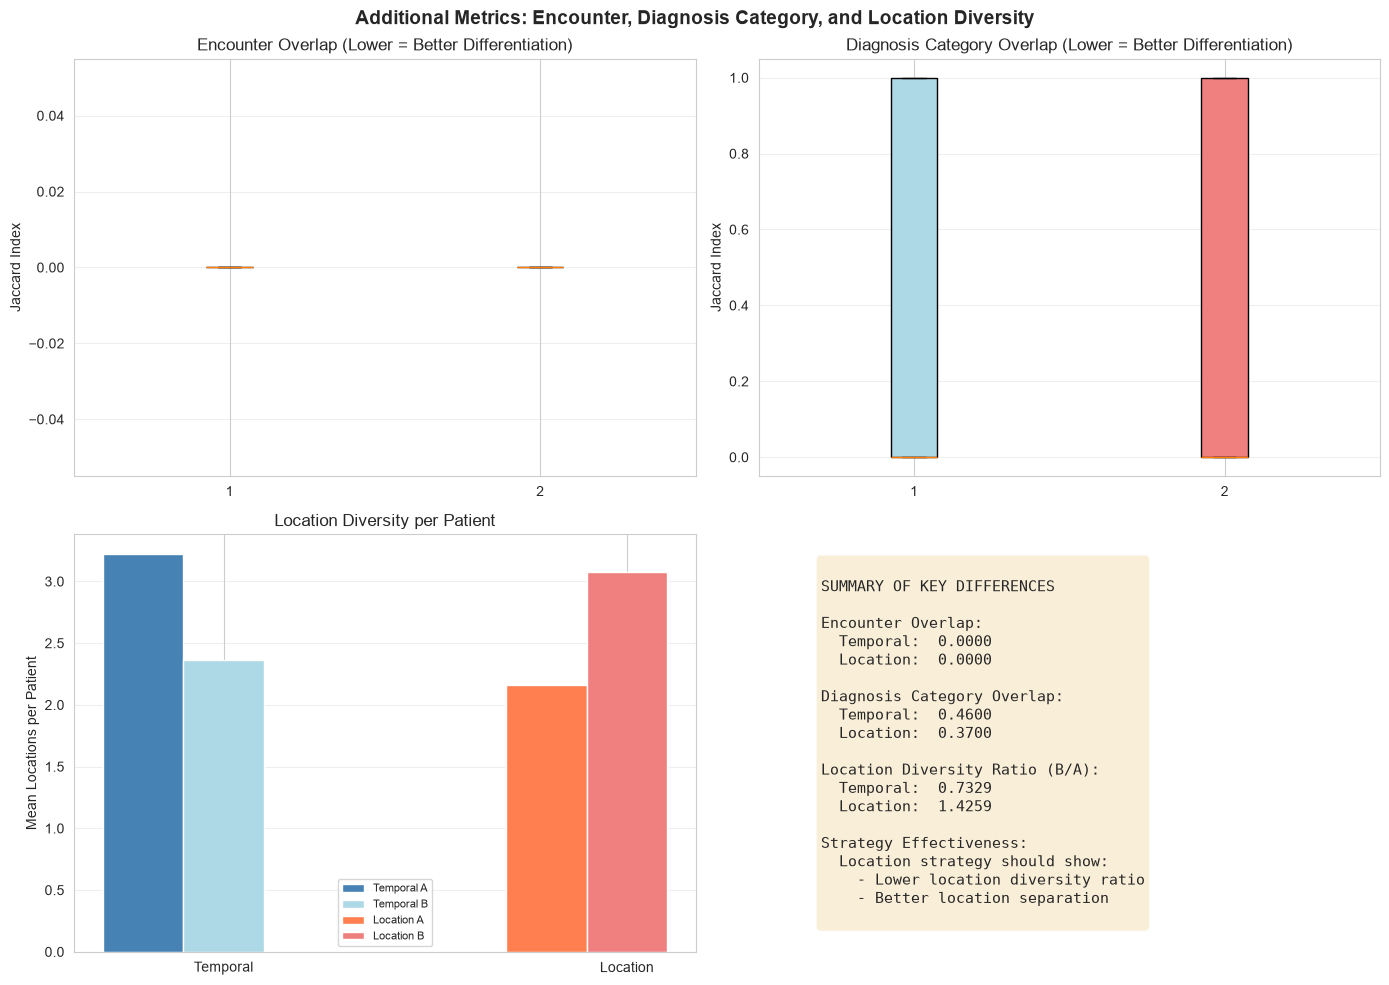

In [34]:
# Visualize additional metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Additional Metrics: Encounter, Diagnosis Category, and Location Diversity", fontsize=14, fontweight='bold')

# Encounter Overlap
ax = axes[0, 0]
temporal_enc = [d["jaccard"] for d in temporal_additional['encounter_overlap']['data']]
location_enc = [d["jaccard"] for d in location_additional['encounter_overlap']['data']]

data_to_plot = [temporal_enc, location_enc]
bp = ax.boxplot(data_to_plot, label=['Temporal', 'Location'], patch_artist=True)
colors = ['lightblue', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_ylabel("Jaccard Index")
ax.set_title("Encounter Overlap (Lower = Better Differentiation)")
ax.grid(axis='y', alpha=0.3)

# Diagnosis Category Overlap
ax = axes[0, 1]
temporal_cat = [d["jaccard"] for d in temporal_additional['diagnosis_category_overlap']['data']]
location_cat = [d["jaccard"] for d in location_additional['diagnosis_category_overlap']['data']]

data_to_plot = [temporal_cat, location_cat]
bp = ax.boxplot(data_to_plot, label=['Temporal', 'Location'], patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_ylabel("Jaccard Index")
ax.set_title("Diagnosis Category Overlap (Lower = Better Differentiation)")
ax.grid(axis='y', alpha=0.3)

# Location Diversity per Patient
ax = axes[1, 0]
temporal_loc_a = [d["locations_a"] for d in temporal_additional['location_diversity']['data']]
temporal_loc_b = [d["locations_b"] for d in temporal_additional['location_diversity']['data']]
location_loc_a = [d["locations_a"] for d in location_additional['location_diversity']['data']]
location_loc_b = [d["locations_b"] for d in location_additional['location_diversity']['data']]

x_pos = np.arange(2)
width = 0.2

ax.bar(x_pos[0] - width, np.mean(temporal_loc_a), width, label='Temporal A', color='steelblue')
ax.bar(x_pos[0], np.mean(temporal_loc_b), width, label='Temporal B', color='lightblue')
ax.bar(x_pos[1] - width, np.mean(location_loc_a), width, label='Location A', color='coral')
ax.bar(x_pos[1], np.mean(location_loc_b), width, label='Location B', color='lightcoral')

ax.set_ylabel("Mean Locations per Patient")
ax.set_title("Location Diversity per Patient")
ax.set_xticks(x_pos)
ax.set_xticklabels(['Temporal', 'Location'])
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Summary comparison
ax = axes[1, 1]
ax.axis('off')

summary_text = f"""
SUMMARY OF KEY DIFFERENCES

Encounter Overlap:
  Temporal:  {temporal_additional['encounter_overlap']['mean_overlap']:.4f}
  Location:  {location_additional['encounter_overlap']['mean_overlap']:.4f}

Diagnosis Category Overlap:
  Temporal:  {temporal_additional['diagnosis_category_overlap']['mean_overlap']:.4f}
  Location:  {location_additional['diagnosis_category_overlap']['mean_overlap']:.4f}

Location Diversity Ratio (B/A):
  Temporal:  {temporal_additional['location_diversity']['diversity_ratio']:.4f}
  Location:  {location_additional['location_diversity']['diversity_ratio']:.4f}

Strategy Effectiveness:
  Location strategy should show:
    - Lower location diversity ratio
    - Better location separation
"""

ax.text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
        verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()


## Compare Overlap Metrics Across Strategies

Create summary tables comparing overlap statistics between temporal and location strategies.

In [35]:
print("\n" + "=" * 80)
print("COMPARISON BETWEEN STRATEGIES")
print("=" * 80 + "\n")

# Create comparison dataframe
comparison_data = []

for resource_type in resource_types:
    temporal_data = temporal_summary[resource_type]
    location_data = location_summary[resource_type]
    
    comparison_data.append({
        "Resource Type": resource_type,
        "Strategy": "Temporal",
        "Patients with Resource": temporal_data.get('patients_with_resource', 0),
        "Jaccard Mean": temporal_data.get('jaccard_mean', np.nan),
        "Jaccard Median": temporal_data.get('jaccard_median', np.nan),
        "Jaccard Std": temporal_data.get('jaccard_std', np.nan),
        "Overlap % (A)": temporal_data.get('overlap_pct_a_mean', np.nan),
        "Overlap % (B)": temporal_data.get('overlap_pct_b_mean', np.nan),
        "Avg Overlap %": temporal_data.get('overlap_pct_mean', np.nan),
        "Total Overlap": temporal_data.get('intersection_total', 0)
    })
    
    comparison_data.append({
        "Resource Type": resource_type,
        "Strategy": "Location",
        "Patients with Resource": location_data.get('patients_with_resource', 0),
        "Jaccard Mean": location_data.get('jaccard_mean', np.nan),
        "Jaccard Median": location_data.get('jaccard_median', np.nan),
        "Jaccard Std": location_data.get('jaccard_std', np.nan),
        "Overlap % (A)": location_data.get('overlap_pct_a_mean', np.nan),
        "Overlap % (B)": location_data.get('overlap_pct_b_mean', np.nan),
        "Avg Overlap %": location_data.get('overlap_pct_mean', np.nan),
        "Total Overlap": location_data.get('intersection_total', 0)
    })

comparison_df = pd.DataFrame(comparison_data)

print("Summary Table:")
print(comparison_df.to_string(index=False))

# Create pivot tables for easier comparison
print("\n\nJaccard Index (Mean) - Temporal vs Location:")
jaccard_pivot = comparison_df.pivot_table(
    values="Jaccard Mean",
    index="Resource Type",
    columns="Strategy"
)
print(jaccard_pivot)

print("\n\nAverage Overlap % - Temporal vs Location:")
overlap_pivot = comparison_df.pivot_table(
    values="Avg Overlap %",
    index="Resource Type",
    columns="Strategy"
)
print(overlap_pivot)


COMPARISON BETWEEN STRATEGIES

Summary Table:
Resource Type Strategy  Patients with Resource  Jaccard Mean  Jaccard Median  Jaccard Std  Overlap % (A)  Overlap % (B)  Avg Overlap %  Total Overlap
    Condition Temporal                     100      0.065071             0.0     0.101264      11.632633      11.292233      11.462433            282
    Condition Location                     100      0.063898             0.0     0.103510      12.348367      11.114300      11.731334            344
   Medication Temporal                     100      0.003984             0.0     0.008501       1.056340       0.695825       0.876083             32
   Medication Location                     100      0.003687             0.0     0.009851       1.128028       0.617222       0.872625             32
    Procedure Temporal                     100      0.042015             0.0     0.092022       8.365514       8.658924       8.512219             77
    Procedure Location                     100      0

## Visualize Overlap Statistics

Generate visualizations to show overlap distributions for conditions, medications, and procedures. Compare overlap metrics across strategies visually.

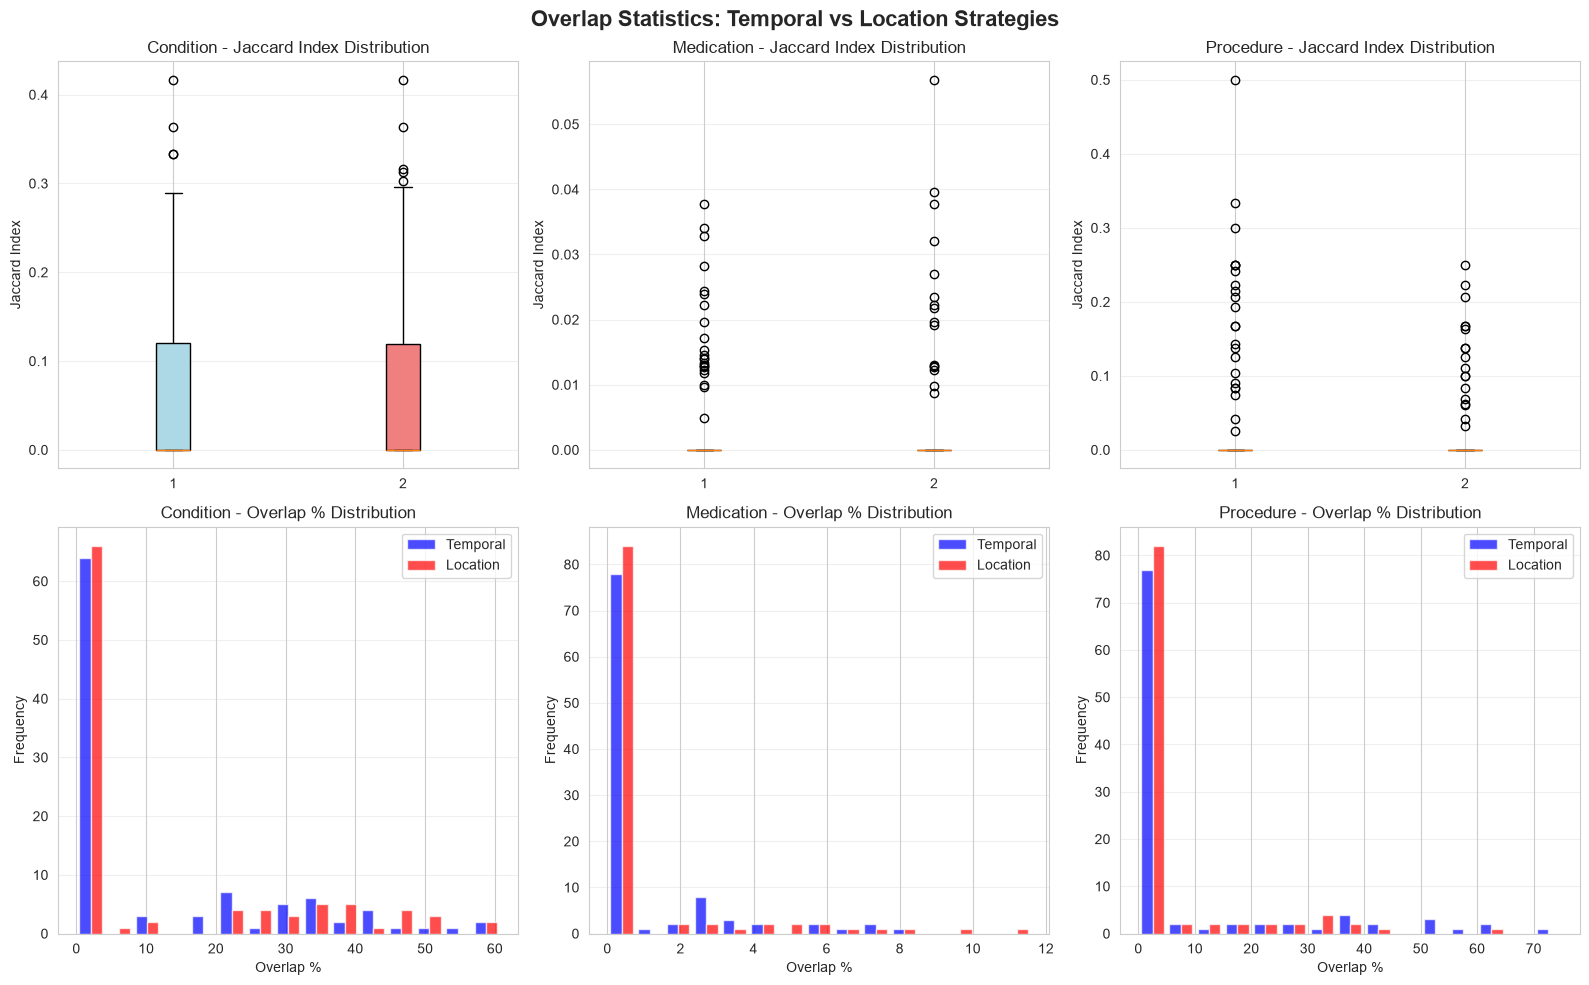

In [36]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Overlap Statistics: Temporal vs Location Strategies", fontsize=16, fontweight='bold')

for idx, resource_type in enumerate(resource_types):
    # Temporal data
    temporal_overlap_data = temporal_results["resource_types"][resource_type].get("overlap_data", [])
    location_overlap_data = location_results["resource_types"][resource_type].get("overlap_data", [])
    
    temporal_jaccard = [d["jaccard_index"] for d in temporal_overlap_data]
    location_jaccard = [d["jaccard_index"] for d in location_overlap_data]
    
    temporal_overlap_pct = [d["avg_overlap_pct"] for d in temporal_overlap_data]
    location_overlap_pct = [d["avg_overlap_pct"] for d in location_overlap_data]
    
    # Row 1: Jaccard Index Distribution
    ax = axes[0, idx]
    data_to_plot = [temporal_jaccard, location_jaccard]
    bp = ax.boxplot(data_to_plot, label=['Temporal', 'Location'], patch_artist=True)
    
    # Color the boxes
    colors = ['lightblue', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax.set_ylabel("Jaccard Index")
    ax.set_title(f"{resource_type} - Jaccard Index Distribution")
    ax.grid(axis='y', alpha=0.3)
    
    # Row 2: Overlap Percentage Distribution
    ax = axes[1, idx]
    ax.hist([temporal_overlap_pct, location_overlap_pct], 
            bins=15, label=['Temporal', 'Location'], alpha=0.7, color=['blue', 'red'])
    ax.set_xlabel("Overlap %")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{resource_type} - Overlap % Distribution")
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

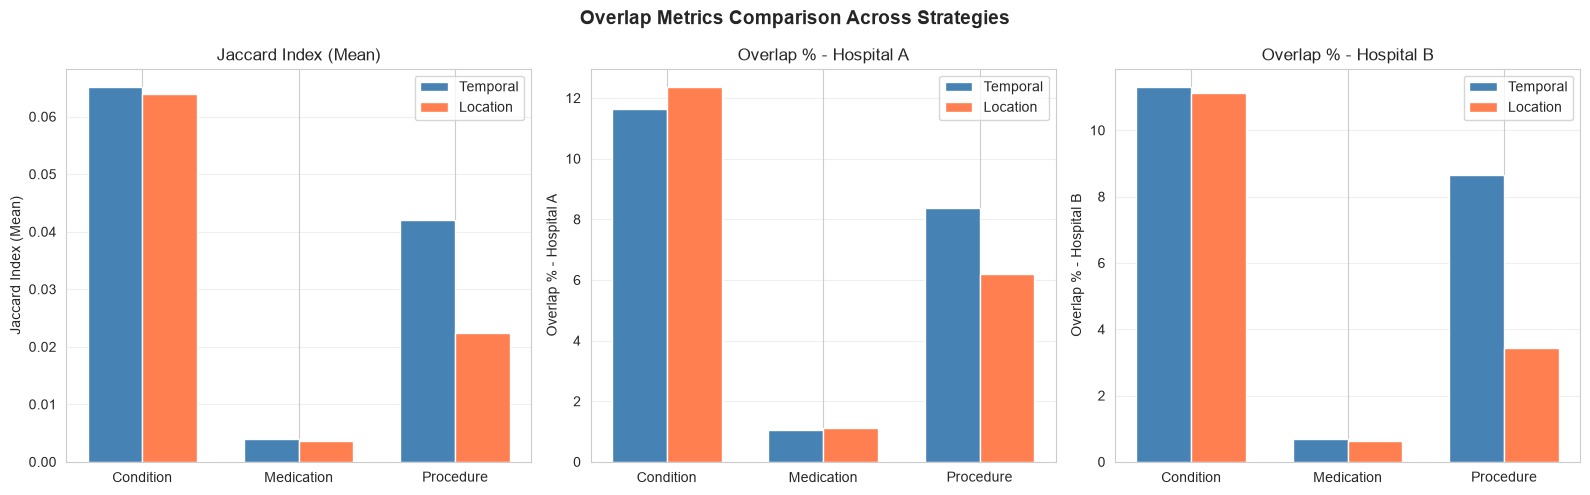

In [37]:
# Bar charts comparing strategies
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Overlap Metrics Comparison Across Strategies", fontsize=14, fontweight='bold')

metrics_to_compare = [
    ("jaccard_mean", "Jaccard Index (Mean)"),
    ("overlap_pct_a_mean", "Overlap % - Hospital A"),
    ("overlap_pct_b_mean", "Overlap % - Hospital B")
]

for idx, (metric_key, title) in enumerate(metrics_to_compare):
    ax = axes[idx]
    
    temporal_values = [
        temporal_summary[rt].get(metric_key, 0) for rt in resource_types
    ]
    location_values = [
        location_summary[rt].get(metric_key, 0) for rt in resource_types
    ]
    
    x = np.arange(len(resource_types))
    width = 0.35
    
    ax.bar(x - width/2, temporal_values, width, label='Temporal', color='steelblue')
    ax.bar(x + width/2, location_values, width, label='Location', color='coral')
    
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(resource_types)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

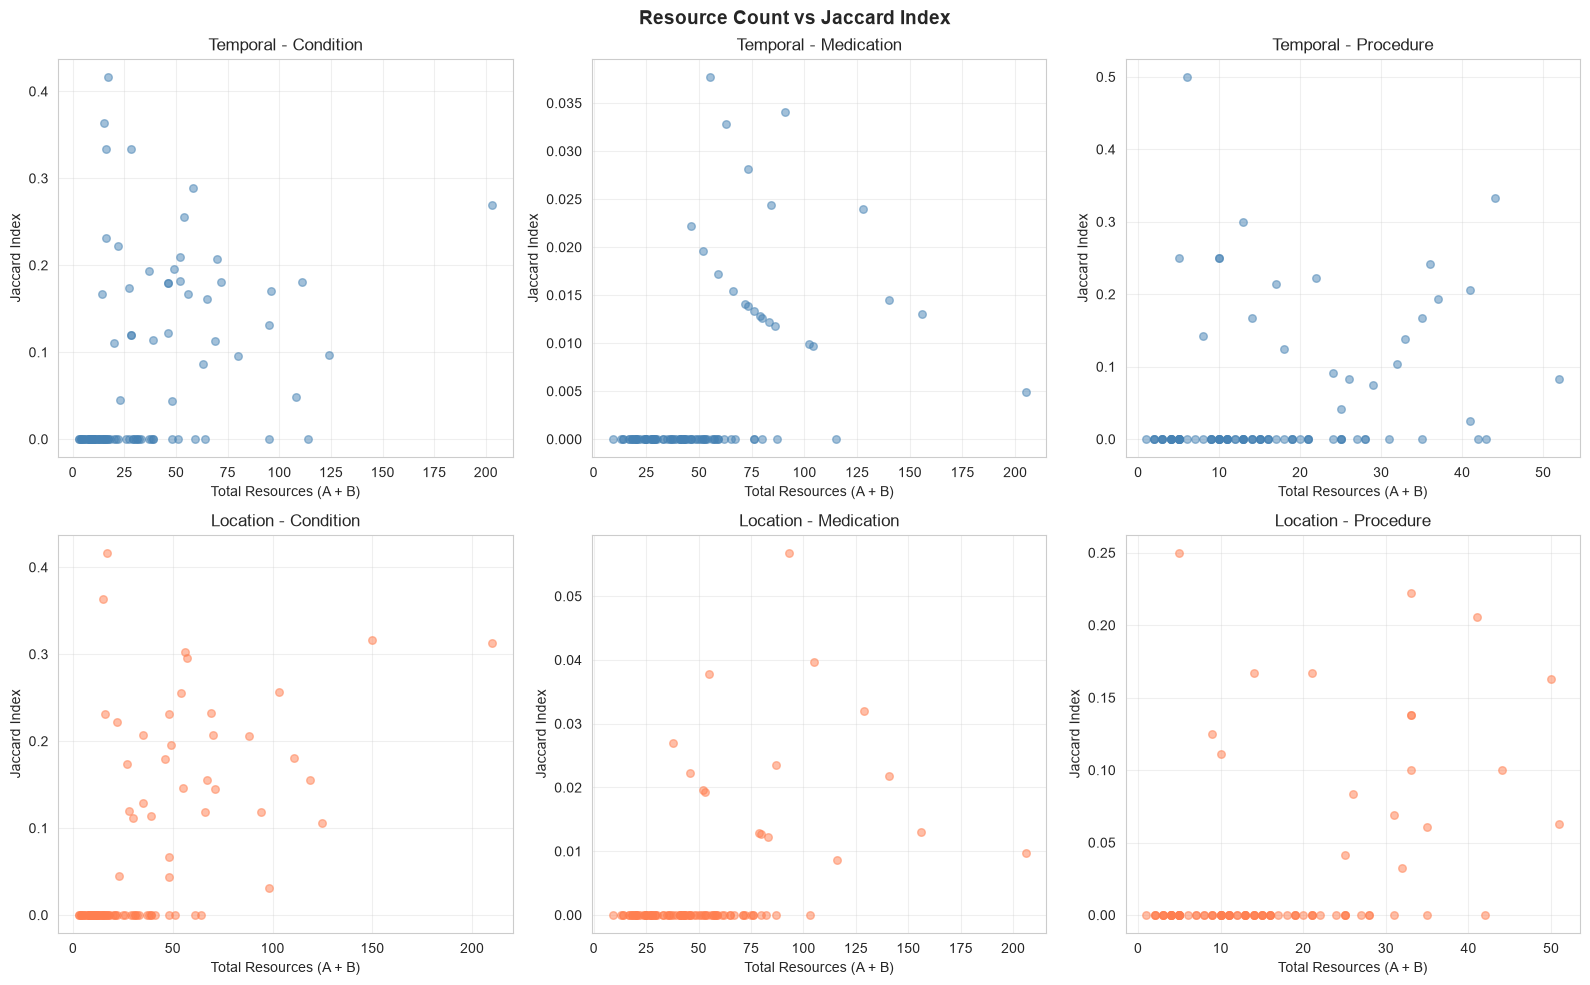

In [38]:
# Scatter plot: Resource count vs Jaccard Index
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Resource Count vs Jaccard Index", fontsize=14, fontweight='bold')

for idx, resource_type in enumerate(resource_types):
    # Temporal
    temporal_overlap_data = temporal_results["resource_types"][resource_type].get("overlap_data", [])
    temporal_total_count = [d["count_a"] + d["count_b"] for d in temporal_overlap_data]
    temporal_jaccard = [d["jaccard_index"] for d in temporal_overlap_data]
    
    ax = axes[0, idx]
    ax.scatter(temporal_total_count, temporal_jaccard, alpha=0.5, s=30, color='steelblue')
    ax.set_xlabel("Total Resources (A + B)")
    ax.set_ylabel("Jaccard Index")
    ax.set_title(f"Temporal - {resource_type}")
    ax.grid(alpha=0.3)
    
    # Location
    location_overlap_data = location_results["resource_types"][resource_type].get("overlap_data", [])
    location_total_count = [d["count_a"] + d["count_b"] for d in location_overlap_data]
    location_jaccard = [d["jaccard_index"] for d in location_overlap_data]
    
    ax = axes[1, idx]
    ax.scatter(location_total_count, location_jaccard, alpha=0.5, s=30, color='coral')
    ax.set_xlabel("Total Resources (A + B)")
    ax.set_ylabel("Jaccard Index")
    ax.set_title(f"Location - {resource_type}")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

This analysis measures the overlap between hospital_A and hospital_B bundles for two split strategies:

### Key Metrics Explained:

- **Jaccard Index**: Measures the similarity between two sets. Value between 0 and 1, where 1 indicates complete overlap and 0 indicates no overlap.
  - Formula: |A ∩ B| / |A ∪ B|

- **Overlap %**: Percentage of resources in one hospital that are also present in the other hospital.
  - Overlap % (A): Percentage of hospital A resources that appear in hospital B
  - Overlap % (B): Percentage of hospital B resources that appear in hospital A

- **Intersection Count**: Total number of resources that appear in both hospitals.

### Interpretation:

- **High Jaccard Index / Overlap %**: Indicates that patients' resources are distributed similarly across both hospitals, suggesting less differentiation.
- **Low Jaccard Index / Overlap %**: Indicates that patients' resources are well-separated between hospitals, suggesting good stratification by the split strategy.

Using 100 MIMIC patients as a pilot cohort, both temporal and location-based fragmentation strategies successfully generated paired patient fragments with zero encounter overlap (mean encounter Jaccard = 0.0), confirming that no encounters were duplicated across hospitals. Resource-level overlap was intentionally low: condition overlap averaged ~11.5%, procedure overlap ranged from ~4.8% (location) to ~8.5% (temporal), and medication overlap was <1% for both strategies. Mean Jaccard indices were correspondingly low (conditions ≈ 0.064, procedures 0.022–0.042, medications ≈ 0.004), while the median Jaccard was 0 for all resource types, indicating that more than half of patient pairs shared no identical resources at all. This suggests that the generated pairs are not near-duplicates and cannot be matched simply by exact resource overlap.

At the semantic level, however, meaningful continuity remains. Diagnosis-category overlap averaged 0.46 for temporal splits and 0.37 for location splits, showing that although exact Condition resources differ, patients still retain clinically coherent histories across fragments. Temporal fragmentation preserves more clinical similarity, while location fragmentation creates a harder matching problem by reducing both procedure overlap (8.5% → 4.8%) and diagnosis-category overlap (0.46 → 0.37). Location diversity analysis further supports this distinction: the location strategy separates care contexts more strongly, while temporal splitting primarily separates encounters chronologically. Overall, the benchmark appears to occupy a useful middle ground: fragments are neither trivial duplicates nor completely unrelated, creating a realistic setting for evaluating entity matching methods that leverage longitudinal clinical history.